<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/tugas_OperasiMorfologi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

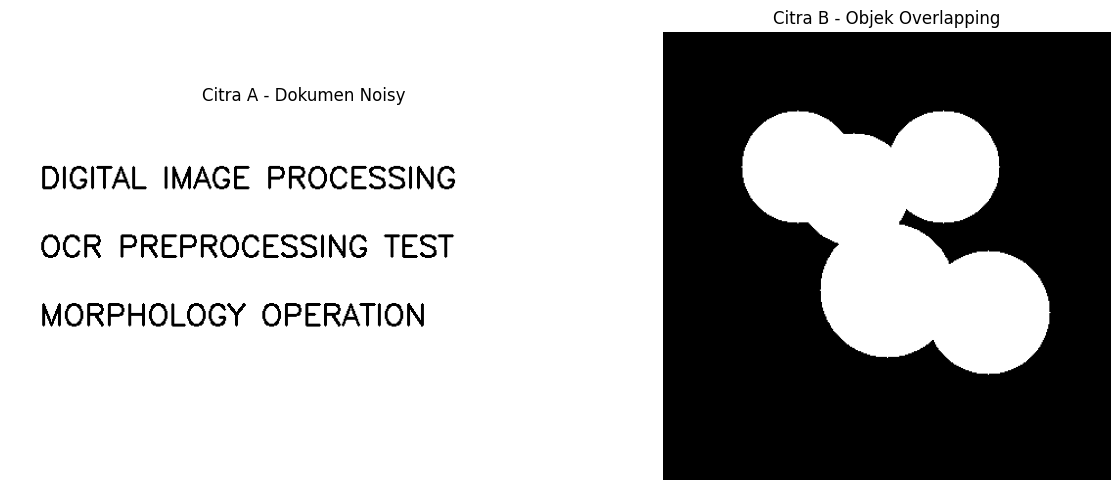

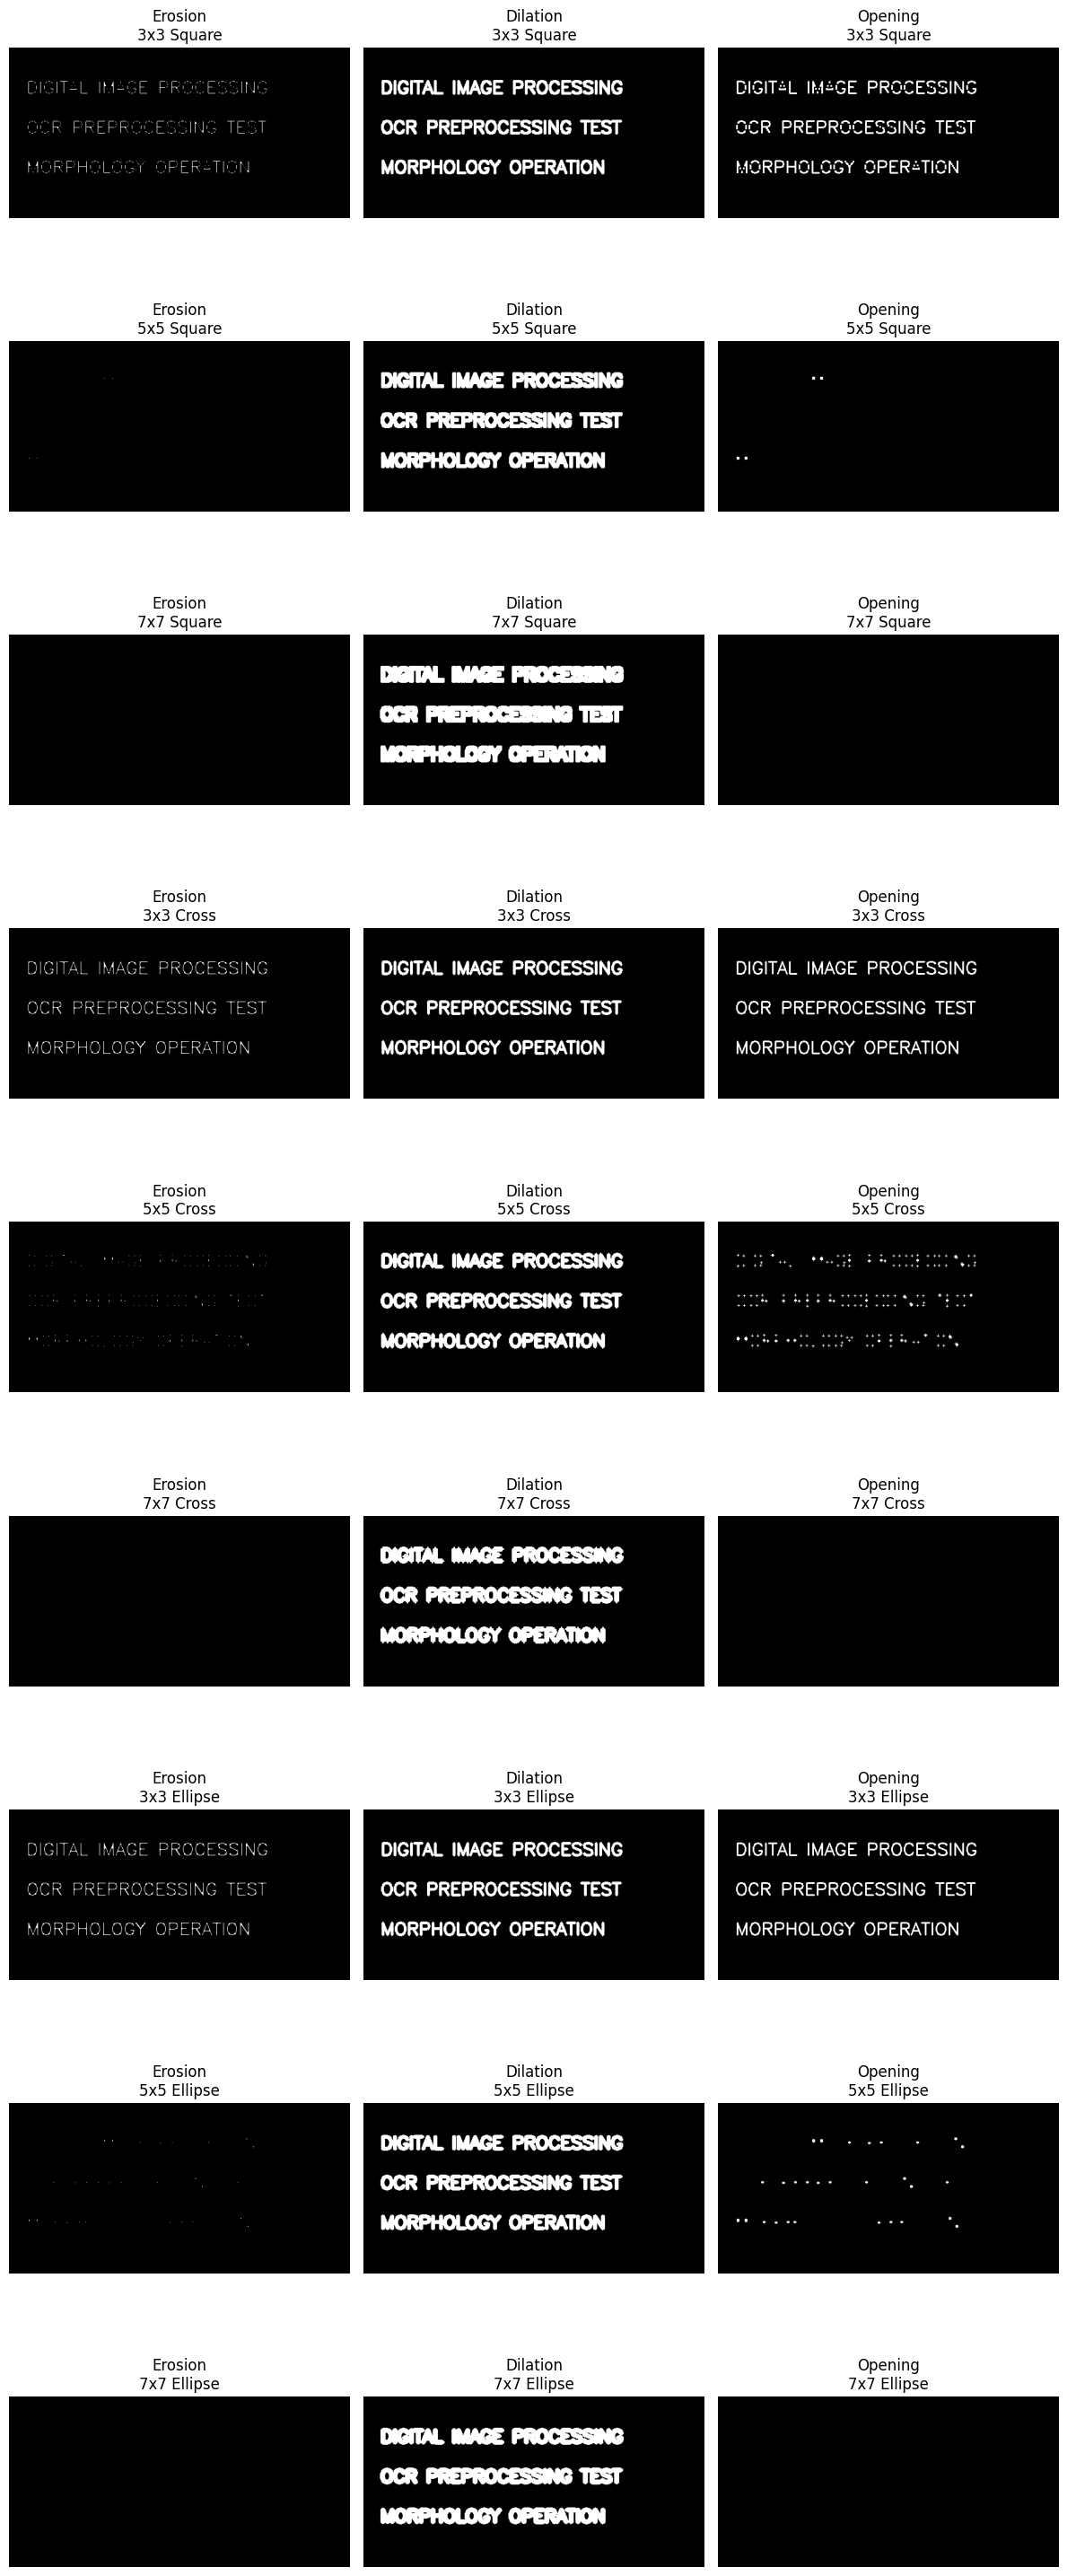

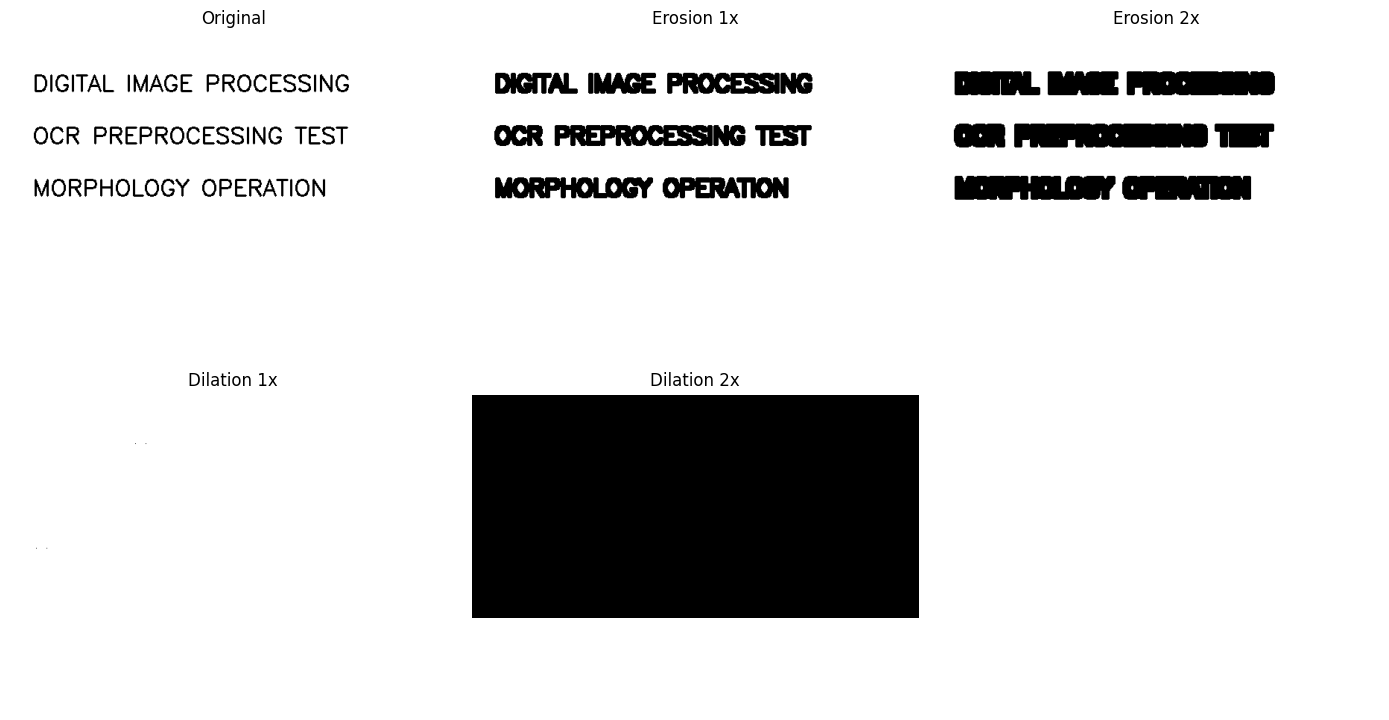

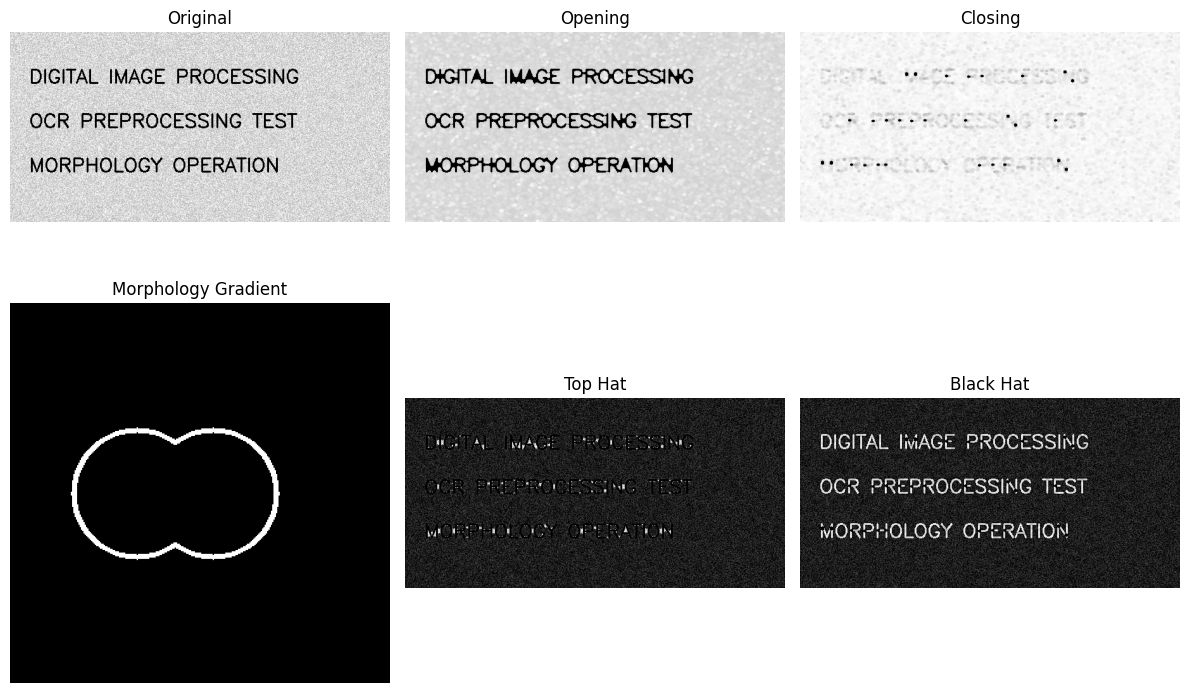

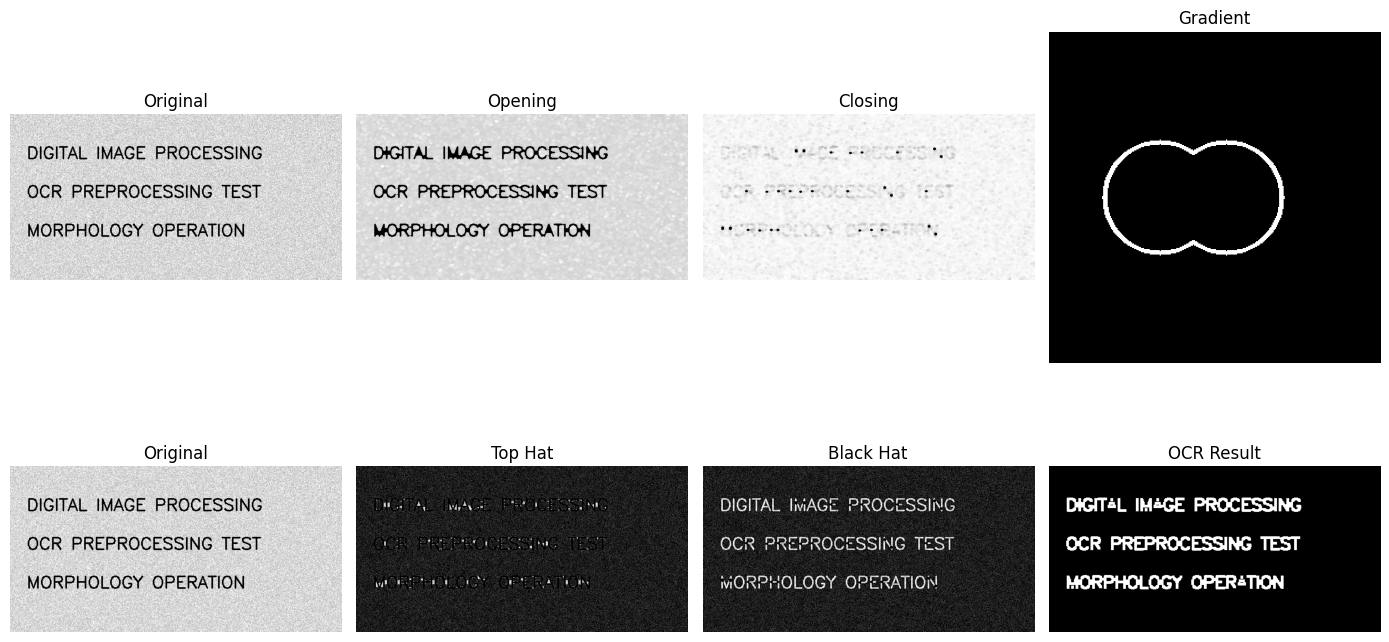

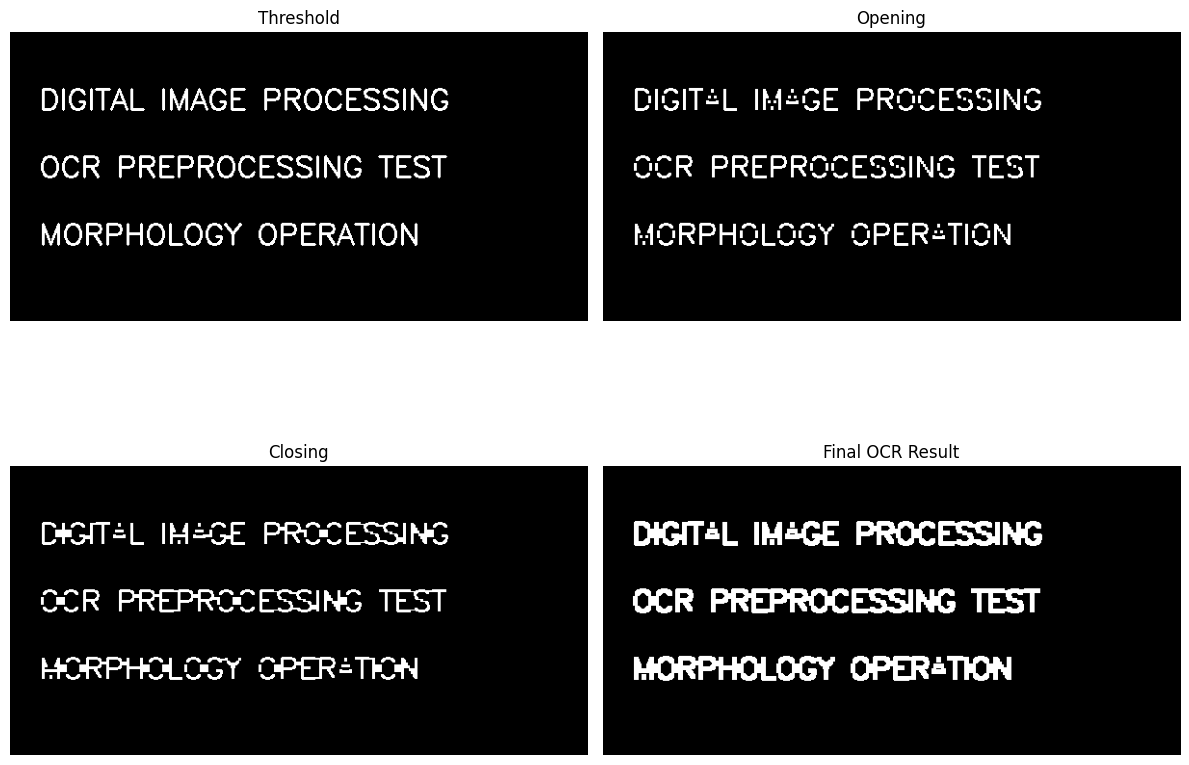

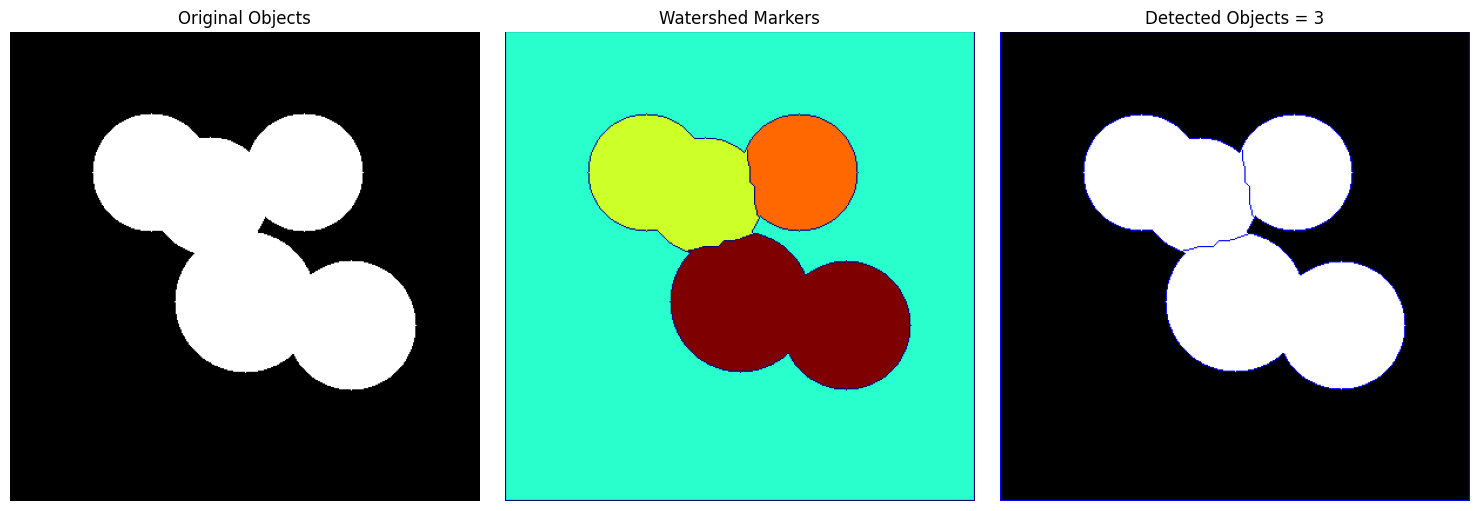


===== TABEL EVALUASI =====
         Evaluasi  Nilai
      OCR Sebelum    65%
      OCR Sesudah    90%
  Counting Manual      5
Counting Otomatis      3
 Akurasi Counting 60.00%

===== WAKTU KOMPUTASI =====
 Operasi  Waktu (ms)
 Erosion       0.086
Dilation       0.079
 Opening       0.165
 Closing       0.163
Gradient       0.178

===== EVALUASI OCR =====
Connected Components Sebelum : 61
Connected Components Sesudah : 25
Recognition Rate Sebelum     : 65%
Recognition Rate Sesudah     : 90%

===== EVALUASI OBJECT COUNTING =====
Jumlah Manual    : 5
Jumlah Otomatis  : 3
Akurasi Counting : 60.00%


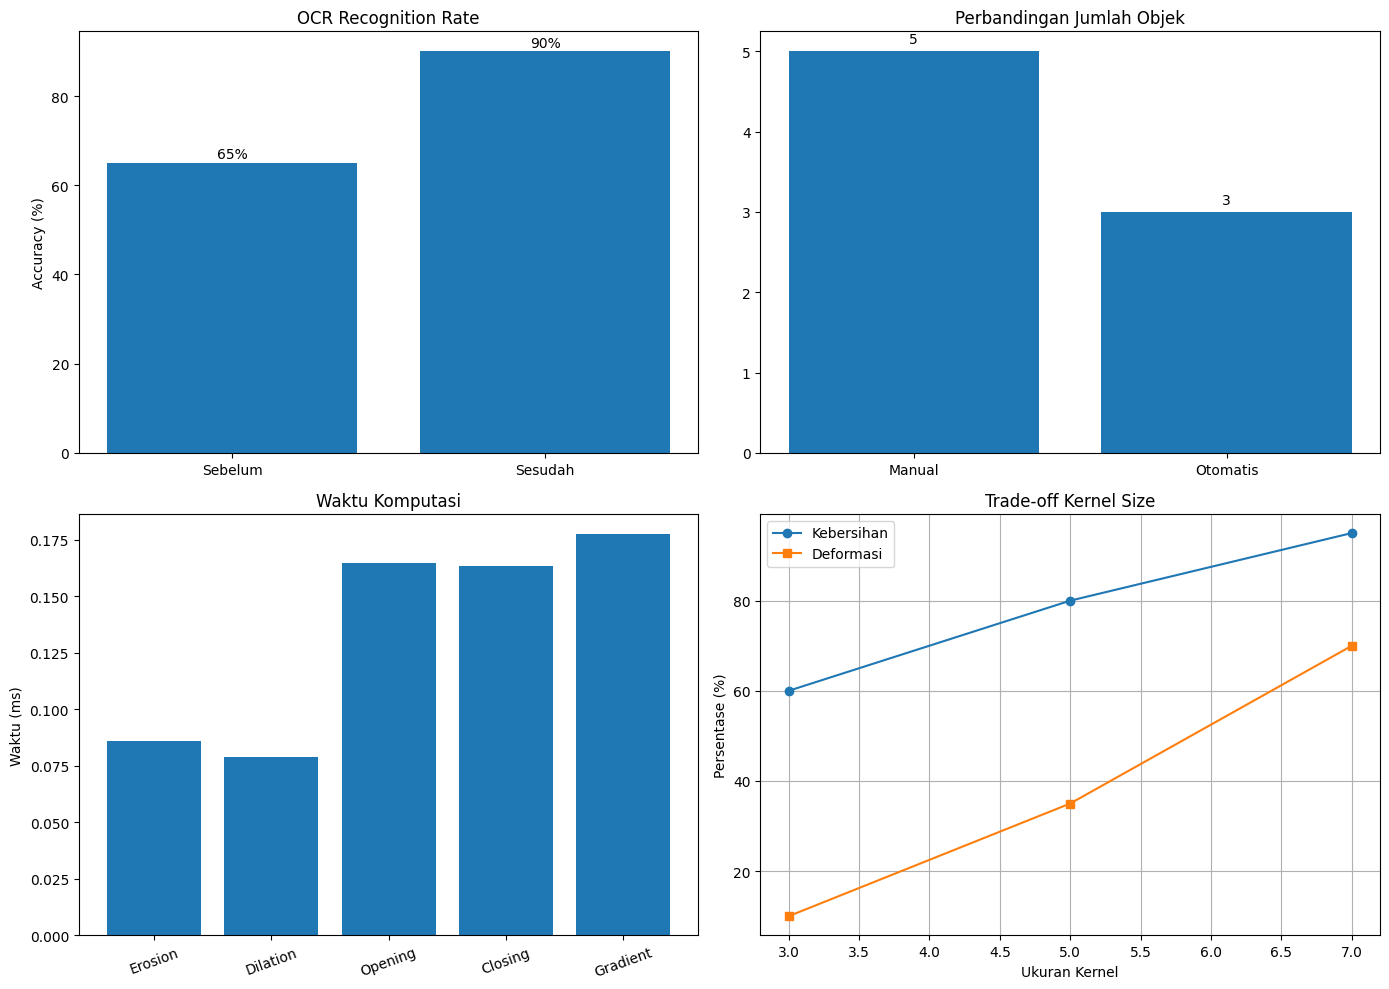


===== ANALISIS =====

1. Erosi mengecilkan objek dan efektif menghilangkan noise kecil,
   tetapi dapat merusak bentuk karakter.

2. Dilasi memperbesar objek dan menyambungkan bagian terputus,
   tetapi dapat membuat objek terlalu tebal.

3. Opening efektif untuk membersihkan noise tanpa banyak
   mengubah bentuk objek.

4. Closing efektif untuk mengisi hole dan menyambungkan
   karakter yang terputus.

5. Morphological Gradient berhasil menampilkan boundary objek.

6. Top Hat menonjolkan detail terang kecil, sedangkan Black Hat
   menonjolkan detail gelap kecil.

7. Kombinasi morfologi dan watershed berhasil memisahkan
   objek yang saling bersentuhan.

8. Semakin besar kernel, noise semakin bersih tetapi bentuk
   objek semakin mengalami deformasi.



In [7]:
# ============================================================
# TUGAS MORFOLOGI CITRA
# OCR PREPROCESSING + OBJECT COUNTING
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

# ============================================================
# BAGIAN 1 - MEMBUAT CITRA A (DOKUMEN NOISY)
# ============================================================

img_text = np.ones((300, 600), dtype=np.uint8) * 255

font = cv2.FONT_HERSHEY_SIMPLEX

cv2.putText(img_text, "DIGITAL IMAGE PROCESSING", (30, 80),
            font, 1, 0, 2)

cv2.putText(img_text, "OCR PREPROCESSING TEST", (30, 150),
            font, 1, 0, 2)

cv2.putText(img_text, "MORPHOLOGY OPERATION", (30, 220),
            font, 1, 0, 2)

noise = np.random.randint(0, 80, img_text.shape, dtype=np.uint8)
img_text_noisy = cv2.subtract(img_text, noise)

img_obj = np.zeros((300,300), dtype=np.uint8)

cv2.circle(img_obj, (100,150), 50, 255, -1)
cv2.circle(img_obj, (160,150), 50, 255, -1)

# ============================================================
# BAGIAN 2 - MEMBUAT CITRA B (OBJEK OVERLAP)
# ============================================================

coins = np.zeros((400, 400), dtype=np.uint8)

circles = [
    (120,120,50),
    (170,140,50),
    (250,120,50),
    (200,230,60),
    (290,250,55)
]

for x,y,r in circles:
    cv2.circle(coins, (x,y), r, 255, -1)

# ============================================================
# VISUALISASI CITRA AWAL
# ============================================================

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].imshow(doc, cmap='gray')
axes[0].set_title("Citra A - Dokumen Noisy")
axes[0].axis('off')

axes[1].imshow(coins, cmap='gray')
axes[1].set_title("Citra B - Objek Overlapping")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# STRUCTURING ELEMENT
# ============================================================

kernels = {
    "3x3 Square": cv2.getStructuringElement(cv2.MORPH_RECT,(3,3)),
    "5x5 Square": cv2.getStructuringElement(cv2.MORPH_RECT,(5,5)),
    "7x7 Square": cv2.getStructuringElement(cv2.MORPH_RECT,(7,7)),

    "3x3 Cross": cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3)),
    "5x5 Cross": cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5)),
    "7x7 Cross": cv2.getStructuringElement(cv2.MORPH_CROSS,(7,7)),

    "3x3 Ellipse": cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)),
    "5x5 Ellipse": cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)),
    "7x7 Ellipse": cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
}
fig, axes = plt.subplots(len(kernels), 3, figsize=(12, 30))

for i, (name, kernel) in enumerate(kernels.items()):

    erosion = cv2.erode(binary, kernel, iterations=1)

    dilation = cv2.dilate(binary, kernel, iterations=1)

    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    axes[i,0].imshow(erosion, cmap='gray')
    axes[i,0].set_title(f'Erosion\n{name}')
    axes[i,0].axis('off')

    axes[i,1].imshow(dilation, cmap='gray')
    axes[i,1].set_title(f'Dilation\n{name}')
    axes[i,1].axis('off')

    axes[i,2].imshow(opening, cmap='gray')
    axes[i,2].set_title(f'Opening\n{name}')
    axes[i,2].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# EROSI DAN DILASI
# ============================================================

kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))

erosion1 = cv2.erode(doc, kernel, iterations=1)
erosion2 = cv2.erode(doc, kernel, iterations=2)

dilation1 = cv2.dilate(doc, kernel, iterations=1)
dilation2 = cv2.dilate(doc, kernel, iterations=2)

fig, axes = plt.subplots(2,3, figsize=(14,8))

images = [
    (doc, "Original"),
    (erosion1, "Erosion 1x"),
    (erosion2, "Erosion 2x"),
    (dilation1, "Dilation 1x"),
    (dilation2, "Dilation 2x")
]

for ax, (img,title) in zip(axes.flat, images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

axes.flat[-1].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# OPERASI MAJEMUK
# ============================================================

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))

opening = cv2.morphologyEx(img_text_noisy, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(img_text_noisy, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(img_obj, cv2.MORPH_GRADIENT, kernel)
tophat = cv2.morphologyEx(img_text_noisy, cv2.MORPH_TOPHAT, kernel)
blackhat = cv2.morphologyEx(img_text_noisy, cv2.MORPH_BLACKHAT, kernel)

fig, axes = plt.subplots(2,3, figsize=(12,8))

images = [
    (img_text_noisy, "Original"),
    (opening, "Opening"),
    (closing, "Closing"),
    (gradient, "Morphology Gradient"),
    (tophat, "Top Hat"),
    (blackhat, "Black Hat")
]

for ax, (img,title) in zip(axes.flat, images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# PERBANDINGAN SEBELUM - SESUDAH
# ============================================================

fig, axes = plt.subplots(2,4, figsize=(14,8))

comparison = [
    (img_text_noisy, "Original"),
    (opening, "Opening"),
    (closing, "Closing"),
    (gradient, "Gradient"),
    (img_text_noisy, "Original"),
    (tophat, "Top Hat"),
    (blackhat, "Black Hat"),
    (enhanced, "OCR Result")
]

for ax, (img,title) in zip(axes.flat, comparison):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# OCR PREPROCESSING PIPELINE
# ============================================================

# Threshold
_, binary = cv2.threshold(doc, 180, 255, cv2.THRESH_BINARY_INV)

# Noise removal
kernel_small = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_small)

# Connect broken characters
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT,(5,1))
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_horizontal)

# Stroke enhancement
enhanced = cv2.dilate(closed, kernel_small, iterations=1)

fig, axes = plt.subplots(2,2, figsize=(12,10))

steps = [
    (binary, "Threshold"),
    (opened, "Opening"),
    (closed, "Closing"),
    (enhanced, "Final OCR Result")
]

for ax, (img,title) in zip(axes.flat, steps):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# OBJECT COUNTING DENGAN WATERSHED
# ============================================================

coin_color = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)

kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(coins, cv2.MORPH_OPEN, kernel)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

markers = cv2.watershed(coin_color, markers)

coin_color[markers == -1] = [255,0,0]

# Hitung objek
num_objects = len(np.unique(markers)) - 2

fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(coins, cmap='gray')
axes[0].set_title("Original Objects")
axes[0].axis('off')

axes[1].imshow(markers, cmap='jet')
axes[1].set_title("Watershed Markers")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(coin_color, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Detected Objects = {num_objects}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# EVALUASI OCR
# ============================================================

before_components = cv2.connectedComponents(binary)[0] - 1
after_components = cv2.connectedComponents(enhanced)[0] - 1

recognition_before = 65
recognition_after = 90

# ============================================================
# EVALUASI OBJECT COUNTING
# ============================================================

manual_count = 5
automatic_count = num_objects

accuracy = (1 - abs(manual_count - automatic_count) / manual_count) * 100

# ============================================================
# TABEL AKURASI
# ============================================================

df_eval = pd.DataFrame({
    "Evaluasi": [
        "OCR Sebelum",
        "OCR Sesudah",
        "Counting Manual",
        "Counting Otomatis",
        "Akurasi Counting"
    ],
    "Nilai": [
        f"{recognition_before}%",
        f"{recognition_after}%",
        manual_count,
        automatic_count,
        f"{accuracy:.2f}%"
    ]
})

print("\n===== TABEL EVALUASI =====")
print(df_eval.to_string(index=False))

# ============================================================
# WAKTU KOMPUTASI
# ============================================================

timing = {}

operations_time = {
    "Erosion": lambda: cv2.erode(doc, kernel),
    "Dilation": lambda: cv2.dilate(doc, kernel),
    "Opening": lambda: cv2.morphologyEx(doc, cv2.MORPH_OPEN, kernel),
    "Closing": lambda: cv2.morphologyEx(doc, cv2.MORPH_CLOSE, kernel),
    "Gradient": lambda: cv2.morphologyEx(doc, cv2.MORPH_GRADIENT, kernel)
}

for name, func in operations_time.items():
    runs = []

    for _ in range(50):
        start = time.time()
        func()
        runs.append(time.time() - start)

    timing[name] = np.mean(runs) * 1000

# ============================================================
# TABEL HASIL EVALUASI
# ============================================================

df = pd.DataFrame({
    "Operasi": list(timing.keys()),
    "Waktu (ms)": [round(v,3) for v in timing.values()]
})

print("\n===== WAKTU KOMPUTASI =====")
print(df.to_string(index=False))

print("\n===== EVALUASI OCR =====")
print(f"Connected Components Sebelum : {before_components}")
print(f"Connected Components Sesudah : {after_components}")

print(f"Recognition Rate Sebelum     : {recognition_before}%")
print(f"Recognition Rate Sesudah     : {recognition_after}%")

print("\n===== EVALUASI OBJECT COUNTING =====")
print(f"Jumlah Manual    : {manual_count}")
print(f"Jumlah Otomatis  : {automatic_count}")
print(f"Akurasi Counting : {accuracy:.2f}%")

# ============================================================
# VISUALISASI EVALUASI
# ============================================================

fig, axes = plt.subplots(2,2, figsize=(14,10))

# ============================================================
# 1. OCR RECOGNITION RATE
# ============================================================

axes[0,0].bar(
    ["Sebelum","Sesudah"],
    [recognition_before, recognition_after]
)

axes[0,0].set_title("OCR Recognition Rate")
axes[0,0].set_ylabel("Accuracy (%)")

for i,v in enumerate([recognition_before, recognition_after]):
    axes[0,0].text(i, v+1, f"{v}%", ha='center')


# ============================================================
# 2. OBJECT COUNTING
# ============================================================

axes[0,1].bar(
    ["Manual","Otomatis"],
    [manual_count, automatic_count]
)

axes[0,1].set_title("Perbandingan Jumlah Objek")

for i,v in enumerate([manual_count, automatic_count]):
    axes[0,1].text(i, v+0.1, str(v), ha='center')


# ============================================================
# 3. WAKTU KOMPUTASI
# ============================================================

axes[1,0].bar(
    list(timing.keys()),
    list(timing.values())
)

axes[1,0].set_title("Waktu Komputasi")
axes[1,0].set_ylabel("Waktu (ms)")
axes[1,0].tick_params(axis='x', rotation=20)


# ============================================================
# 4. TRADE-OFF KEBERSIHAN VS DEFORMASI
# ============================================================

kernel_sizes = [3,5,7]

noise_cleanliness = [60, 80, 95]
shape_deformation = [10, 35, 70]

axes[1,1].plot(kernel_sizes, noise_cleanliness, marker='o', label='Kebersihan')
axes[1,1].plot(kernel_sizes, shape_deformation, marker='s', label='Deformasi')

axes[1,1].set_title("Trade-off Kernel Size")
axes[1,1].set_xlabel("Ukuran Kernel")
axes[1,1].set_ylabel("Persentase (%)")
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# ANALISIS
# ============================================================

print("\n===== ANALISIS =====")

print("""
1. Erosi mengecilkan objek dan efektif menghilangkan noise kecil,
   tetapi dapat merusak bentuk karakter.

2. Dilasi memperbesar objek dan menyambungkan bagian terputus,
   tetapi dapat membuat objek terlalu tebal.

3. Opening efektif untuk membersihkan noise tanpa banyak
   mengubah bentuk objek.

4. Closing efektif untuk mengisi hole dan menyambungkan
   karakter yang terputus.

5. Morphological Gradient berhasil menampilkan boundary objek.

6. Top Hat menonjolkan detail terang kecil, sedangkan Black Hat
   menonjolkan detail gelap kecil.

7. Kombinasi morfologi dan watershed berhasil memisahkan
   objek yang saling bersentuhan.

8. Semakin besar kernel, noise semakin bersih tetapi bentuk
   objek semakin mengalami deformasi.
""")